# 1. Getting Started with Cobrabox - iEEG Data Exploration

Authors: *[COBRA group](https://cobra.cs.cas.cz), Institute of Computer Science, The Czech Academy of Sciences*

<div align="left">
<img src="Images/Logo_CAS_ICS.png" align="left" width="254" alt="logo ICS">
</div>


<br>
<br>

---------------------

This is the first of three notebooks that together form a complete, reproducible example of
using [CobraBox](https://github.com/cobragroup/cobrabox) on an intracranial EEG (iEEG) dataset:

1. ***Getting Started & Data Exploration (this notebook)*** introduces the toolbox and walks, step-by-step, through the example dataset. It is read-only: it produces no files and is meant purely for familiarisation.
2. ***Preprocessing the Zurich HFO dataset*** turns the raw recordings into clean, segmented, analysis-ready data saved to disk.
3. ***Analysis using the Zurich HFO dataset*** computes directed connectivity, runs the statistics, and produces the main results.

Notebooks 2 and 3 follow the pipeline of the accompanying study (Stergiadis C, Halliday DM, Kazis D, Klados MA. *High-frequency directed networks can identify epileptogenic tissue and predict surgical outcome in drug-resistant epilepsy*. Epilepsy Research. 2026 May 28;226:107838. doi: [10.1016/j.eplepsyres.2026.107838](https://doi.org/10.1016/j.eplepsyres.2026.107838)).


> For a general getting started and installation visit the [CobraBox documentation](https://github.com/cobragroup/cobrabox/tree/main/docs), or access the help of individual functions as usual, typing `help(cb.FunctionName)` or `cb.FunctionName?` in an interactive session.



## Contents of this notebook

1. CobraBox setup
2. The example dataset
3. Patient metadata
4. Loading the raw recordings
5. The raw signal in the time domain
6. Power-line filtering (50 Hz notch)
7. The bipolar montage
8. Where to go next …


## Import dependencies
> TODO: state the dependencies and point to documentation for installation.

This Notebook requires a ***python*** (>=3.11) installation together with ***xarray*** (>2026.2.0) and ***cobrabox*** (>=X.Y). For visualization it employs ***Matplotlib***. Please make sure these packages are installed in the python environment this notebook is running.


In [5]:
# Python standard library imports
from pathlib import Path

# Third-party imports
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import cobrabox as cb

# Local libraries and modules
import utils


In [6]:
# Set the local path to store the data
cb.set_dataset_dir(Path(".") / "data", persist=False)

## 1. Patient Metadata

The CSV file contains metadata for 20 patients: surgical outcome (ILAE grade), full channel
lists, which channels were resected, and which were excluded by the pipeline (e.g. due to
artefacts or missing data). Only patients with ILAE-1 outcome (seizure-free after surgery)
are used in the main analysis.

In [2]:
patient_info = load_patient_info()

header = f"{'subject':<10} {'outcome':<10} {'n_resected':>10}   {'n_pipeline_excluded':>20}"
print(header)
print("-" * len(header))

n_ilae1 = 0
for sub_id, info in patient_info.items():
    n_res = len(info["resected"])
    n_excl = len(info["pipeline_exclusions"])
    print(f"{sub_id:<10} {info['outcome']:<10} {n_res:>10} resected   {n_excl:>3} pipeline excluded")
    if info["outcome"].startswith("ILAE1"):
        n_ilae1 += 1

print(f"\nILAE-1 subjects: {n_ilae1} / {len(patient_info)}")

subject    outcome    n_resected    n_pipeline_excluded
-------------------------------------------------------
sub-01     ILAE1               9 resected    20 pipeline excluded
sub-02     ILAE1              12 resected    32 pipeline excluded
sub-03     ILAE1              12 resected    20 pipeline excluded
sub-04     ILAE1              12 resected    32 pipeline excluded
sub-05     ILAE1              12 resected    32 pipeline excluded
sub-06     ILAE1              12 resected    32 pipeline excluded
sub-07     ILAE3              12 resected    32 pipeline excluded
sub-08     ILAE3              12 resected    32 pipeline excluded
sub-09     ILAE5              12 resected    32 pipeline excluded
sub-10     ILAE1               3 resected     0 pipeline excluded
sub-11     ILAE1               3 resected     0 pipeline excluded
sub-12     ILAE1              21 resected     0 pipeline excluded
sub-13     ILAE1               3 resected     0 pipeline excluded
sub-14     ILAE1              

## 2. Loading Raw Data

We load the BrainVision iEEG recordings for sub-01 via `cb.load_dataset`. Each subject has
multiple runs (continuous recordings of varying length). Inspecting the runs gives us the
sampling rate, duration, and channel count before any preprocessing.

In [3]:
ds = cb.load_dataset("zurich_ieeg", subset=["sub-01"])

print(f"Loaded {len(ds)} runs for sub-01")
for run_idx, item in enumerate(ds):
    fs = item.sampling_rate
    n_samples = item.data.sizes["time"]
    duration = n_samples / fs
    n_channels = item.data.sizes["space"]
    print(f"  Run {run_idx}: {fs:.0f} Hz, {duration:.1f} s, {n_channels} channels")

/home/pidnebesna/Documents/Projects/Other/cobrabox/src/cobrabox/dataset_loader.py:555: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_brainvision(str(path), preload=True, verbose=False)


Loaded 28 runs for sub-01
  Run 0: 2000 Hz, 300.0 s, 50 channels
  Run 1: 2000 Hz, 300.0 s, 50 channels
  Run 2: 2000 Hz, 300.0 s, 50 channels
  Run 3: 2000 Hz, 300.0 s, 50 channels
  Run 4: 2000 Hz, 300.0 s, 50 channels
  Run 5: 2000 Hz, 400.0 s, 50 channels
  Run 6: 2000 Hz, 360.0 s, 50 channels
  Run 7: 2000 Hz, 300.0 s, 50 channels
  Run 8: 2000 Hz, 360.0 s, 50 channels
  Run 9: 2000 Hz, 360.0 s, 50 channels
  Run 10: 2000 Hz, 386.0 s, 50 channels
  Run 11: 2000 Hz, 335.0 s, 50 channels
  Run 12: 2000 Hz, 334.0 s, 50 channels
  Run 13: 2000 Hz, 354.0 s, 50 channels
  Run 14: 2000 Hz, 354.0 s, 50 channels
  Run 15: 2000 Hz, 300.0 s, 50 channels
  Run 16: 2000 Hz, 300.0 s, 50 channels
  Run 17: 2000 Hz, 300.0 s, 50 channels
  Run 18: 2000 Hz, 300.0 s, 50 channels
  Run 19: 2000 Hz, 300.0 s, 50 channels
  Run 20: 2000 Hz, 300.0 s, 50 channels
  Run 21: 2000 Hz, 392.0 s, 50 channels
  Run 22: 2000 Hz, 300.0 s, 50 channels
  Run 23: 2000 Hz, 300.0 s, 50 channels
  Run 24: 2000 Hz, 300.0

## 3. Channel Inspection

iEEG recordings use **unipolar** (monopolar) channels referenced to a common electrode.
We later convert to a **bipolar montage** by subtracting adjacent contacts on the same
electrode shaft, which cancels common-mode noise and gives a more localised signal.

Some channels are excluded because of:
- **Recording artefacts** (marked in `excluded_channels` by the clinical team)
- **Pipeline exclusions** (flagged during data QC, stored in patient metadata)

**Resected channels** are the bipolar pairs that correspond to tissue removed during surgery.
These are our positive class — we hypothesise they show higher RC.

In [4]:
item0 = ds[0]
subject_id = "sub-01"

all_channels = item0.extra["all_channels"]
excluded_channels = item0.extra.get("excluded_channels", [])
pipeline_exclusions = patient_info[subject_id]["pipeline_exclusions"]
resected = patient_info[subject_id]["resected"]
valid_pairs = get_valid_pairs(item0, subject_id, patient_info)

print(f"Subject: {subject_id}")
print(f"  All bipolar pairs:       {len(all_channels)}")
print(f"  Excluded channels:       {len(excluded_channels)}")
print(f"  Pipeline exclusions:     {len(pipeline_exclusions)}")
print(f"  Resected pairs:          {len(resected)}")
print(f"  Valid pairs (usable):    {len(valid_pairs)}")
print()
print("Resected channels:")
for ch in resected:
    in_valid = "[in valid pairs]" if ch in valid_pairs else "[NOT in valid pairs]"
    print(f"  {ch}  {in_valid}")

  [sub-01] Missing monopolar channels: ['AHL1', 'AHL2', 'AHL3', 'AHL4', 'AHL5', 'AHL6', 'AHL7', 'AHL8']
Subject: sub-01
  All bipolar pairs:       43
  Excluded channels:       0
  Pipeline exclusions:     20
  Resected pairs:          9
  Valid pairs (usable):    20

Resected channels:
  AHR1-AHR2  [in valid pairs]
  AHR2-AHR3  [in valid pairs]
  AHR3-AHR4  [in valid pairs]
  AR1-AR2  [in valid pairs]
  AR2-AR3  [in valid pairs]
  AR3-AR4  [in valid pairs]
  PHR1-PHR2  [in valid pairs]
  PHR2-PHR3  [in valid pairs]
  PHR3-PHR4  [in valid pairs]


## 4. Raw Signal: Time-Series

Before any processing, let's look at the raw iEEG signal. Plotting the first 2 seconds of
a few channels gives a sense of the signal amplitude and any obvious artefacts. Channels are
offset vertically so they don't overlap.

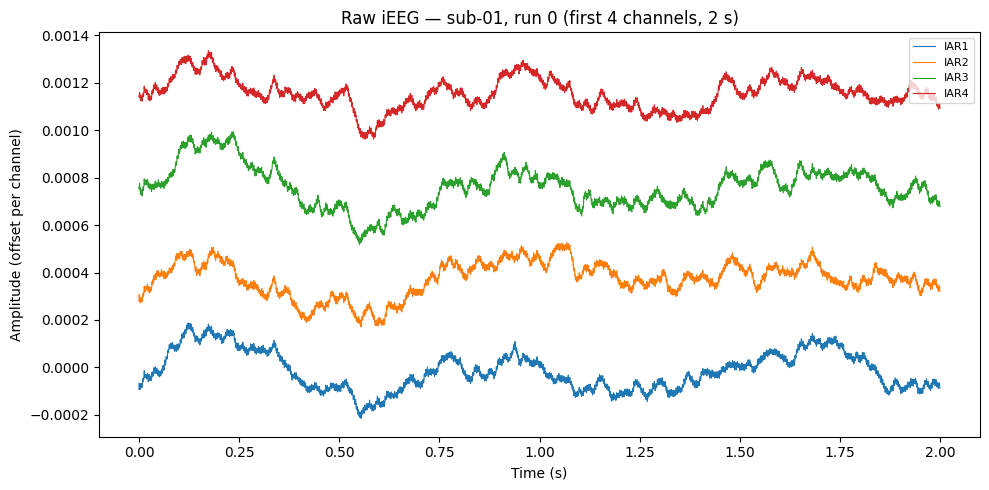

In [5]:
item0 = ds[0]
fs = item0.sampling_rate
n_show_channels = 4
n_show_samples = int(2.0 * fs)

data_snippet = item0.data.isel(space=slice(0, n_show_channels), time=slice(0, n_show_samples))
time_axis = np.arange(n_show_samples) / fs
channel_names = data_snippet.coords["space"].values

offset = float(np.std(data_snippet.values)) * 5

fig, ax = plt.subplots(figsize=(10, 5))
for i, ch in enumerate(channel_names):
    signal = data_snippet.sel(space=ch).values
    ax.plot(time_axis, signal + i * offset, lw=0.8, label=ch)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (offset per channel)")
ax.set_title("Raw iEEG — sub-01, run 0 (first 4 channels, 2 s)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Notch Filtering

iEEG recordings are typically contaminated by **50 Hz power-line noise** (in Europe). We
apply a narrow IIR notch filter at 50 Hz before any further processing. The effect is
visible in the power spectral density (PSD): the 50 Hz peak should disappear after filtering.

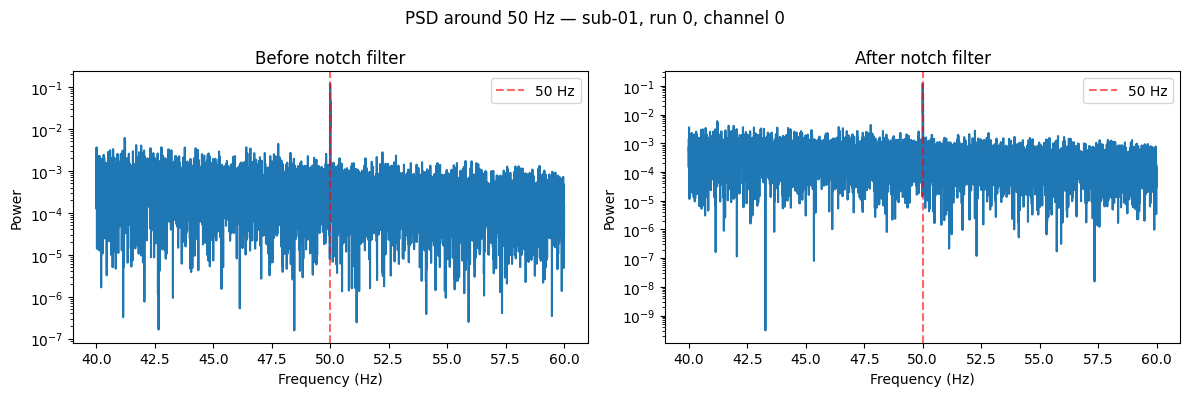

In [6]:
item0 = ds[0]
fs = item0.sampling_rate

raw_ch = item0.data.isel(space=0)
filtered_ch = notch_filter(item0.data, fs=fs).isel(space=0)

def compute_psd(signal, fs):
    spectrum = np.abs(np.fft.rfft(signal.values)) ** 2
    freqs = np.fft.rfftfreq(len(signal), d=1.0 / fs)
    return freqs, spectrum

freqs, psd_raw = compute_psd(raw_ch, fs)
_, psd_filt = compute_psd(filtered_ch, fs)

mask = (freqs >= 40) & (freqs <= 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, psd, title in zip(axes, [psd_raw, psd_filt], ["Before notch filter", "After notch filter"]):
    ax.semilogy(freqs[mask], psd[mask])
    ax.axvline(50, color="red", linestyle="--", alpha=0.6, label="50 Hz")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power")
    ax.set_title(title)
    ax.legend()

fig.suptitle("PSD around 50 Hz — sub-01, run 0, channel 0")
plt.tight_layout()
plt.show()

## 6. Bipolar Montage

The **bipolar montage** subtracts adjacent unipolar contacts on the same electrode shaft
(e.g. AHR2 − AHR1 → "AHR1-AHR2"). This serves two purposes:
1. Cancels common-mode noise (e.g. reference artefacts, global slow waves)
2. Produces a more spatially localised signal, sensitive to activity between the two contacts

Only pairs where both contacts are present, not excluded, and not pipeline-rejected are
used ("valid pairs").

  [sub-01] Missing monopolar channels: ['AHL1', 'AHL2', 'AHL3', 'AHL4', 'AHL5', 'AHL6', 'AHL7', 'AHL8']
Valid bipolar pairs for sub-01 (20 total):
    1. AHR1-AHR2
    2. AHR2-AHR3
    3. AHR3-AHR4
    4. AL1-AL2
    5. AL2-AL3
    6. AL3-AL4
    7. AR1-AR2
    8. AR2-AR3
    9. AR3-AR4
   10. PHR1-PHR2
   11. PHR2-PHR3
   12. PHR3-PHR4
   13. IAR1-IAR2
   14. IAR2-IAR3
   15. IAR3-IAR4
   16. IAR4-IAR5
   17. IAR5-IAR6
   18. IPR1-IPR2
   19. IPR2-IPR3
   20. IPR3-IPR4


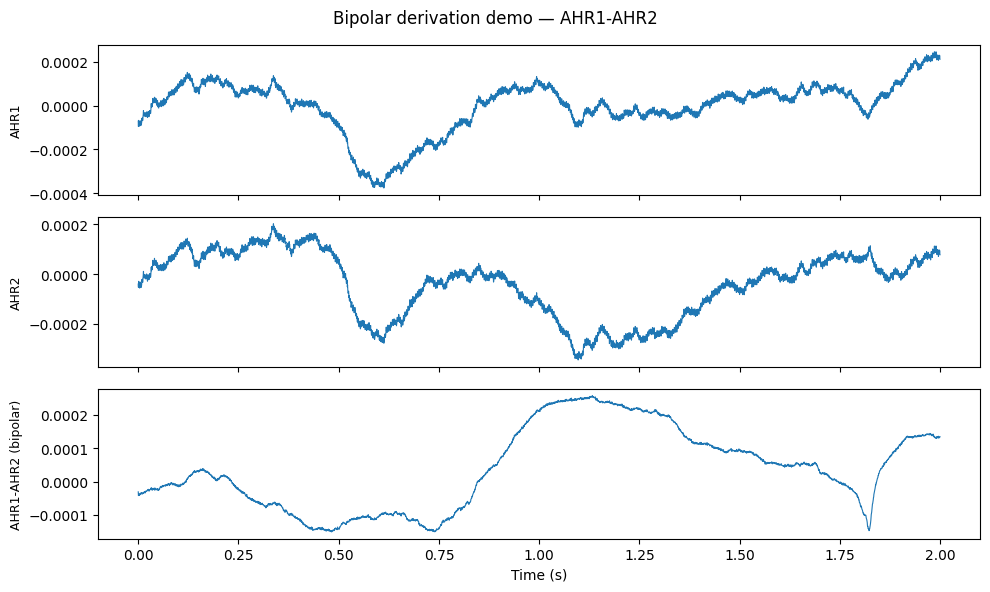

In [7]:
item0 = ds[0]
fs = item0.sampling_rate
valid_pairs = get_valid_pairs(item0, "sub-01", patient_info)

print(f"Valid bipolar pairs for sub-01 ({len(valid_pairs)} total):")
for i, pair in enumerate(valid_pairs):
    print(f"  {i+1:3d}. {pair}")

demo_pair = valid_pairs[0]
ch_a, ch_b = demo_pair.split("-")

filtered_data = notch_filter(item0.data, fs=fs)
n_show = int(2.0 * fs)
t = np.arange(n_show) / fs

sig_a = filtered_data.sel(space=ch_a).isel(time=slice(0, n_show)).values
sig_b = filtered_data.sel(space=ch_b).isel(time=slice(0, n_show)).values
sig_bip = sig_a - sig_b

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, signal, label in zip(axes, [sig_a, sig_b, sig_bip], [ch_a, ch_b, f"{ch_a}-{ch_b} (bipolar)"]):
    ax.plot(t, signal, lw=0.8)
    ax.set_ylabel(label, fontsize=9)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Bipolar derivation demo — {demo_pair}")
plt.tight_layout()
plt.show()

## 7. Segment Extraction

PDC is computed on short, stationary segments. We randomly sample **N_SEGMENTS = 20**
non-overlapping 3-second windows from the available runs. The pool consists of all possible
non-overlapping 3 s windows across all runs; we then draw without replacement.
A fixed random seed (42) ensures reproducibility.

In [8]:
rng = np.random.default_rng(42)

pool_full = []
for run_idx, item in enumerate(ds):
    fs = item.sampling_rate
    n_samples = item.data.sizes["time"]
    seg_len = int(fs * SEGMENT_DURATION)
    n_possible = n_samples // seg_len
    for seg_idx in range(n_possible):
        pool_full.append((run_idx, seg_idx * seg_len))

chosen = build_segment_pool(ds, rng=np.random.default_rng(42))

print(f"Total pool size:    {len(pool_full)} possible segments")
print(f"Segments selected:  {len(chosen)} (N_SEGMENTS = {N_SEGMENTS})")
print()
print(f"{'#':<5} {'run_idx':>8} {'start_sample':>14} {'start_time (s)':>16}")
print("-" * 46)
for i, (run_idx, start_sample) in enumerate(chosen[:5]):
    fs = ds[run_idx].sampling_rate
    start_s = start_sample / fs
    print(f"{i:<5} {run_idx:>8} {start_sample:>14} {start_s:>16.2f}")
print("  ... (showing first 5)")

Total pool size:    3019 possible segments
Segments selected:  20 (N_SEGMENTS = 20)

#      run_idx   start_sample   start_time (s)
----------------------------------------------
0           21         258000           129.00
1           19         498000           249.00
2            5         636000           318.00
3           27         168000            84.00
4           23         150000            75.00
  ... (showing first 5)


## Summary

This notebook demonstrated the key data structures and preprocessing steps for sub-01:

- Patient metadata loaded from CSV: outcome, resected channels, pipeline exclusions
- Raw iEEG runs loaded via `cb.load_dataset`
- 50 Hz notch filter verified in the frequency domain
- Bipolar montage construction from valid unipolar pairs
- Random 3 s segment sampling strategy

**Next step:** `02_preprocessing_and_computation.ipynb` runs this pipeline for all 20 subjects
in batch, computing PDC connectivity and RC values that are saved to disk.